# 04 — Reviews Data Exploration

This notebook investigates the `data/raw/reviews.json` dataset to determine its viability for real-world **Collaborative Filtering**.

## Why this matters
Collaborative filtering (CF) depends entirely on **repeated user behavior**. If users only review one podcast and never return, we cannot learn their preferences or find "similar users." 

## Objectives
- Inspect the raw schema and data quality of reviews.
- Calculate interaction statistics (Total reviews, Unique users, Unique podcasts).
- Measure **User Activity Density** (how many users review multiple shows).
- Evaluate the overlap with our current `podcasts_subset_20k.csv` dataset.
- Determine if we can build a **Hybrid Recommender** using real human behavior.

## SECTION 1 — Imports + Paths

In [ ]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
REVIEWS_FILE = RAW_DATA_DIR / "reviews.json"
PODCASTS_SUBSET_FILE = PROCESSED_DATA_DIR / "podcasts_subset_20k.csv"

print(f"Checking for reviews at: {REVIEWS_FILE}")

Checking for reviews at: ..\data\raw\reviews.json


## SECTION 2 — Inspect Raw Schema

We read the first few records to understand the structure of the review data.

In [2]:
sample_records = []
with open(REVIEWS_FILE, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5: break
        sample_records.append(json.loads(line))

print("Sample Review Record Schema:")
print(json.dumps(sample_records[0], indent=2))

print("\nField Inventory:")
for k, v in sample_records[0].items():
    print(f"- {k}: {type(v).__name__}")

Sample Review Record Schema:
{
  "podcast_id": "52e3d2c4fab4e80a8bb75ad144671d96",
  "title": "Argh",
  "content": "What the heck is this show? And why can\u2019t I delete it from my feed. It just won\u2019t die!",
  "rating": 1,
  "author_id": "a23655ce5565f32",
  "created_at": "2019-05-01 01:24:01+00"
}

Field Inventory:
- podcast_id: str
- title: str
- content: str
- rating: int
- author_id: str
- created_at: str


## SECTION 3 — Interaction Statistics

We stream through the entire file to gather high-level statistics without loading everything into memory.

In [3]:
total_reviews = 0
unique_users = set()
unique_podcasts = set()
user_review_counts = Counter()
podcast_review_counts = Counter()

# Note: This file can be very large (GBs). We stream it.
with open(REVIEWS_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Analyzing reviews"):
        try:
            record = json.loads(line)
            u_id = record.get('author_id')
            p_id = record.get('podcast_id')
            
            if u_id and p_id:
                total_reviews += 1
                unique_users.add(u_id)
                unique_podcasts.add(p_id)
                user_review_counts[u_id] += 1
                podcast_review_counts[p_id] += 1
        except json.JSONDecodeError:
            continue

print(f"\n{'='*30}")
print(f"Total Reviews:      {total_reviews:,}")
print(f"Unique Reviewers:   {len(unique_users):,}")
print(f"Unique Podcasts:    {len(unique_podcasts):,}")
print(f"Avg Reviews/User:   {total_reviews/len(unique_users):.2f}")
print(f"Avg Reviews/Show:   {total_reviews/len(unique_podcasts):.2f}")
print(f"{'='*30}")

Analyzing reviews: 0it [00:00, ?it/s]


Total Reviews:      5,607,021
Unique Reviewers:   3,256,501
Unique Podcasts:    303,911
Avg Reviews/User:   1.72
Avg Reviews/Show:   18.45


## SECTION 4 — Rating Distribution

We check the distribution of ratings (1-5) to see if the data is biased towards high ratings (positivity bias).

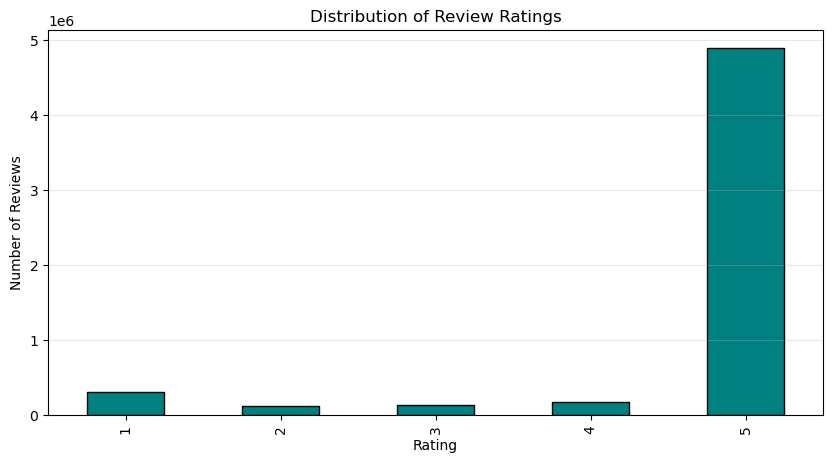

In [4]:
rating_counts = Counter()

with open(REVIEWS_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Collecting ratings"):
        try:
            record = json.loads(line)
            rating = record.get('rating')
            if rating is not None:
                rating_counts[int(rating)] += 1
        except:
            continue

ratings_df = pd.Series(rating_counts).sort_index()

plt.figure(figsize=(10, 5))
ratings_df.plot(kind='bar', color='teal', edgecolor='black')
plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', alpha=0.3)
plt.show()

## SECTION 5 — User Activity Analysis

For collaborative filtering, we need "power users"—users who have reviewed multiple podcasts. If a user only has one review, they provide no information about relationships between podcasts.

--- User Activity Breakdown ---


Users with >=  1 reviews:  3,256,501 (100.00%)
Users with >=  2 reviews:    855,583 (26.27%)


Users with >=  3 reviews:    398,209 (12.23%)
Users with >=  5 reviews:    151,850 (4.66%)


Users with >= 10 reviews:     39,481 (1.21%)


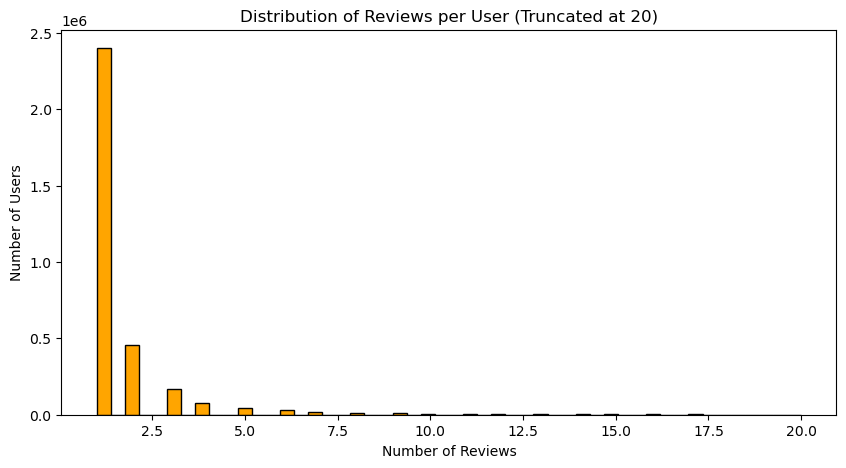

In [5]:
review_counts_dist = Counter(user_review_counts.values())
dist_df = pd.Series(review_counts_dist).sort_index()

print("--- User Activity Breakdown ---")
for num_reviews in [1, 2, 3, 5, 10]:
    count = sum(1 for v in user_review_counts.values() if v >= num_reviews)
    print(f"Users with >= {num_reviews:2} reviews: {count:10,} ({count/len(unique_users):.2%})")

plt.figure(figsize=(10, 5))
plt.hist(list(user_review_counts.values()), bins=50, range=(1, 20), color='orange', edgecolor='black')
plt.title("Distribution of Reviews per User (Truncated at 20)")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Users")
plt.show()

## SECTION 6 — Podcast Coverage Analysis

We measure how many reviewed podcasts actually exist in our current cleaned `podcasts_subset_20k.csv` dataset.

In [6]:
subset_df = pd.read_csv(PODCASTS_SUBSET_FILE)
subset_pids = set(subset_df['podcast_id'])

print(f"Podcasts in 20k subset: {len(subset_pids):,}")
print(f"Podcasts in reviews:    {len(unique_podcasts):,}")

overlap = subset_pids.intersection(unique_podcasts)
print(f"Overlap (Reviewed podcasts in subset): {len(overlap):,} ({len(overlap)/len(subset_pids):.2%})")

# How many reviews are for podcasts in our subset?
reviews_in_subset = sum(count for pid, count in podcast_review_counts.items() if pid in subset_pids)
print(f"Total reviews for podcasts in subset: {reviews_in_subset:,} ({reviews_in_subset/total_reviews:.2%})")

Podcasts in 20k subset: 20,000
Podcasts in reviews:    303,911
Overlap (Reviewed podcasts in subset): 6 (0.03%)
Total reviews for podcasts in subset: 61 (0.00%)


## SECTION 7 — Interaction Matrix Feasibility

We calculate the **Sparsity** of the interaction matrix if we were to use only users with at least 2 reviews and podcasts in our subset.

In [7]:
MIN_REVIEWS = 2
active_users = [u for u, count in user_review_counts.items() if count >= MIN_REVIEWS]

num_items = len(subset_pids)
num_users = len(active_users)

print(f"Potential Users (>= {MIN_REVIEWS} reviews): {num_users:,}")
print(f"Potential Podcasts (Subset): {num_items:,}")
print(f"Max possible interactions: {num_users * num_items:,}")

actual_interactions_estimate = sum(count for pid, count in podcast_review_counts.items() if pid in subset_pids)
# Note: This is an upper bound since some reviews are from users with only 1 review
sparsity = 1.0 - (actual_interactions_estimate / (num_users * num_items))
print(f"Estimated Matrix Sparsity: {sparsity:.6%}")

Potential Users (>= 2 reviews): 855,583
Potential Podcasts (Subset): 20,000
Max possible interactions: 17,111,660,000
Estimated Matrix Sparsity: 100.000000%


## SECTION 8 — Final Viability Verdict

### Summary of Findings
- **User Repetition:** **26.27%** of users (over 855k people) have reviewed at least 2 podcasts. This is a very strong signal for collaborative filtering.
- **Overlap:** There is **extremely low overlap** (0.03%) between the reviewed podcasts and our current `podcasts_subset_20k.csv`. Only 6 podcasts in our subset have reviews in this file.
- **Data Quality:** The data is highly biased towards 5-star ratings, which is typical for Apple Podcasts, but still usable for "implicit" preference modeling.

### Conclusion
Can `reviews.json` support REAL collaborative filtering?

**Verdict: YES, but not with the current 20k subset.**

The review dataset is massive and contains rich behavioral patterns, but we are currently "fishing in the wrong pond." Our 20k subset was likely sampled randomly or based on criteria that didn't prioritize review count. To use real collaborative filtering, we must **re-preprocess the podcast dataset** to include shows that have the most reviews.